<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551 entries, 0 to 550
Data columns (total 18 columns):
 #   Column                                                                                                                 Non-Null Count  Dtype  
---  ------                                                                                                                 --------------  -----  
 0   Timestamp                                                                                                              551 non-null    object 
 1   Your name                                                                                                              551 non-null    object 
 2   Your gender                                                                                                            551 non-null    object 
 3   Your age                                                                                                               551 non-null    object 
 4   Ho

/var/folders/c0/4xxd7l192pb3z1xc3z52h31c0000gn/T/ipykernel_46205/2663545623.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned.loc[:, 'Your age'] = pd.to_numeric(data['Your age'], errors='coerce')


[]
Index(['Timestamp', 'Your name', 'Your gender', 'Your age',
       'How important is exercise to you ?',
       'How do you describe your current level of fitness ?',
       'How often do you exercise?',
       'What barriers, if any, prevent you from exercising more regularly?           (Please select all that apply)',
       'What form(s) of exercise do you currently participate in ?                        (Please select all that apply)',
       'Do you exercise ___________ ?',
       'What time if the day do you prefer to exercise?',
       'How long do you spend exercising per day ?',
       'Would you say you eat a healthy balanced diet ?',
       'What prevents you from eating a healthy balanced diet, If any?                         (Please select all that apply)',
       'How healthy do you consider yourself?',
       'Have you ever recommended your friends to follow a fitness routine?',
       'Have you ever purchased a fitness equipment?',
       'What motivates you to exer

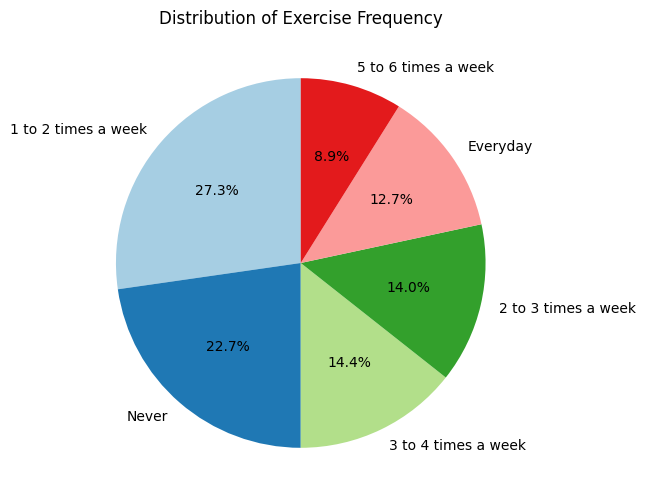

In [1]:
import pandas as pd

# 加载数据集
data = pd.read_csv('健康咨询客户数据集.csv')

# 查看表结构基本信息
print(data.info())

# 显示每一列的空缺值数量
print(data.isnull().sum())

# 删除含有缺失值的行
data_cleaned = data.dropna()

# 转换 'Your age' 列的数据类型为整数类型，并处理异常值
data_cleaned.loc[:, 'Your age'] = pd.to_numeric(data['Your age'], errors='coerce')
data_cleaned = data_cleaned.dropna(subset=['Your age'])
data_cleaned = data_cleaned[data_cleaned['Your age'] >= 0]
data_cleaned.loc[:, 'Your age'] = data_cleaned['Your age'].astype(int)

print(data_cleaned['Your age'].dtype)

# 检查和删除重复值
duplicates_removed = data_cleaned.duplicated().sum()
data_cleaned = data_cleaned.drop_duplicates()

print(f"Removed {duplicates_removed} duplicate rows")

from sklearn.preprocessing import LabelEncoder

# 归一化 'How do you describe your current level of fitness ?' 列
label_encoder = LabelEncoder()
data_cleaned['How do you describe your current level of fitness ?'] = label_encoder.fit_transform(data_cleaned['How do you describe your current level of fitness ?'])

print(data_cleaned['How do you describe your current level of fitness ?'].unique())

from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# 去掉列名中的空格
data.columns = data.columns.str.strip()
# 显示数据集的列名
print(data.columns)

# 删除包含缺失值的行
data_cleaned = data.dropna(subset=['How often do you exercise?'])

# 统计不同健身频率的分布情况
exercise_frequency_counts = data_cleaned['How often do you exercise?'].value_counts()

# 绘制饼图
plt.figure(figsize=(10, 6))
exercise_frequency_counts.plot.pie(autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Distribution of Exercise Frequency')
plt.ylabel('')
plt.show()

import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 填充缺失值
data_filled = data.apply(lambda x: x.fillna(x.mode()[0]))

# 划分数据（测试集占比20%）
train_data, test_data = train_test_split(data_filled, test_size=0.2, random_state=42)

# 保存处理后的数据
cleaned_file_path = '2.1.5_cleaned_data.csv'
data_filled.to_csv(cleaned_file_path, index=False)
